In [1]:
import numpy as np 
import pandas as pd

In [2]:
df=pd.read_csv("customer_shopping_behavior.csv")

In [3]:
df.shape

(3900, 18)

In [4]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [6]:
df.describe(include="all")

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [7]:
df.tail(5)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


In [8]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

# impute missing value with their category

In [9]:
df['Review Rating']=df.groupby('Category')['Review Rating'].transform(lambda x:x.fillna(x.median())) # x refers to category
# transform with group by  applies the function independently to each group and returns a transformed version matching the original index.

In [10]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

# converting column names to lower case and replacing space to _(underscore)

In [11]:
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(' ','_')
df=df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [12]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

# creating new column based on age 

In [13]:
labels=["young-adult",'adult','middle-aged','senior']
df["age_group"]=pd.qcut(df["age"],q=4,labels=labels)

In [14]:
# create column purchase_frequency_days
frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}
df["frequency_mapping"]=df["frequency_of_purchases"].map(frequency_mapping)

In [15]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [16]:
df=df.drop('promo_code_used',axis=1)

# connecting to mysql database 

In [17]:
pip install pymysql sqlalchemy 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [18]:
from sqlalchemy import create_engine 
# Mysql connection
username = "root"
password = "root"
host="127.0.0.1"
port= "3306"
database = "customer_behavior_analysis"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

#write Dataframe to Mysql
table_name = "mytable"  #chosse any table name 
df.to_sql(table_name,engine,if_exists = "replace",index=False)

# read back sample 
pd.read_sql("SELECT * FROM mytable LIMIT 5 ; ",engine )

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,frequency_mapping
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,middle-aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,young-adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,middle-aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,young-adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,middle-aged,365


# exploratory data analysis 

In [19]:
import matplotlib.pyplot as plt 
import seaborn as sns 

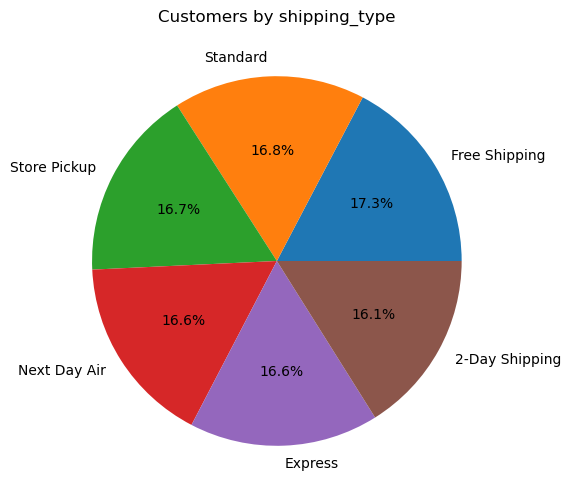

In [38]:
# Count of customers per category
cat_counts = df['shipping_type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(cat_counts.values,
        labels=cat_counts.index,
        autopct='%0.1f%%')
plt.title('Customers by shipping_type')
plt.show()


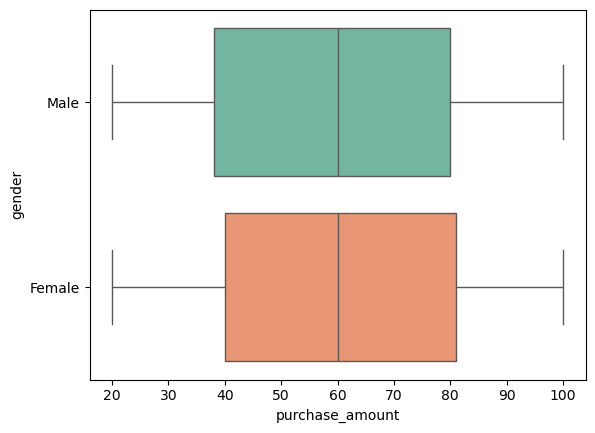

In [22]:
sns.boxplot(data=df,x='purchase_amount',y='gender',hue='gender',palette='Set2',fliersize=3)
plt.show()

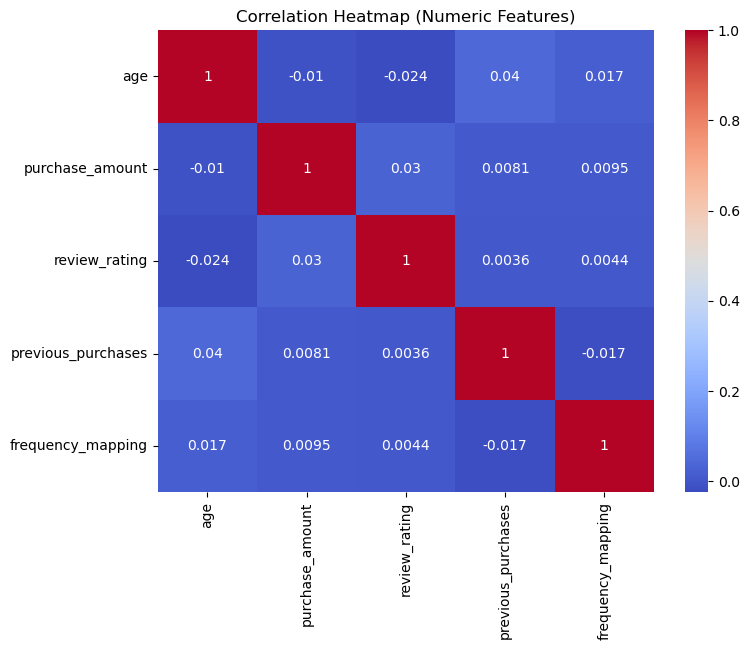

In [23]:
num_cols = ['age', 'purchase_amount', 'review_rating',
            'previous_purchases', 'frequency_mapping']

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm') 
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

Text(0, 0.5, 'Density')

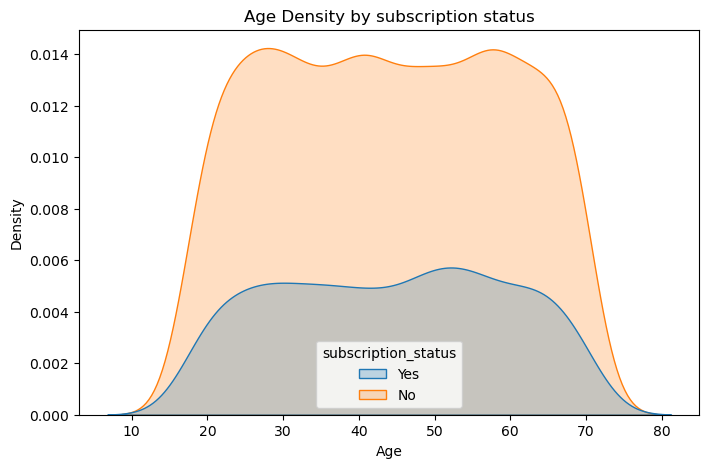

In [34]:
fig, ax = plt.subplots(figsize=(8,5))
sns.kdeplot(data=df,x='age',fill=True,hue='subscription_status',ax=ax)
ax.set_title('Age Density by subscription status')
ax.set_xlabel('Age')
ax.set_ylabel('Density')

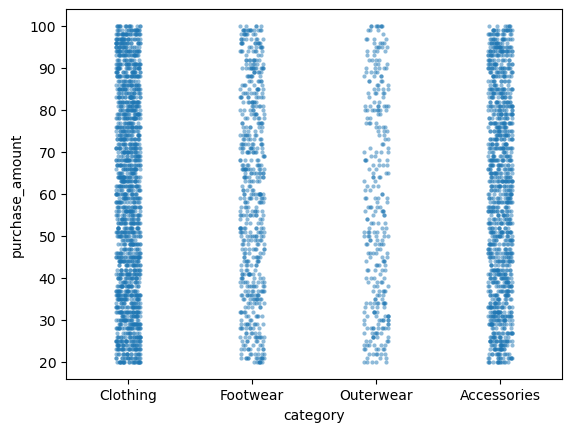

In [36]:
sns.stripplot(data=df, x='category', y='purchase_amount',
              size=3, jitter=True, alpha=0.5)
plt.show()


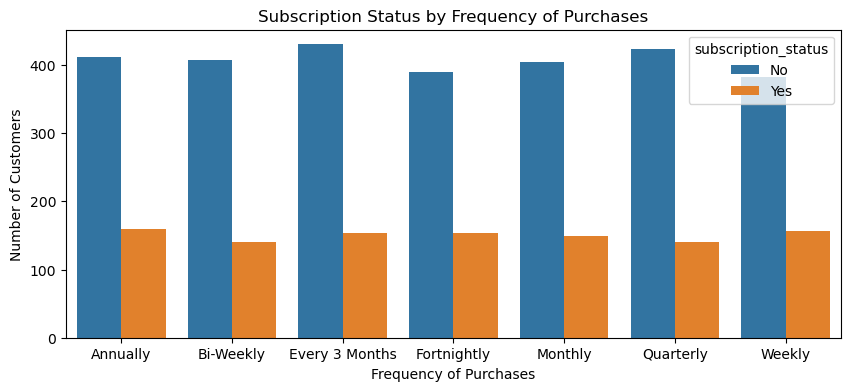

In [73]:
freq_sub = (df.groupby(['frequency_of_purchases', 'subscription_status']).size().reset_index(name='count'))
plt.figure(figsize=(10,4))
sns.barplot(
    data=freq_sub,
    x='frequency_of_purchases',
    y='count',
    hue='subscription_status'
)
plt.title('Subscription Status by Frequency of Purchases')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Number of Customers')
plt.show()

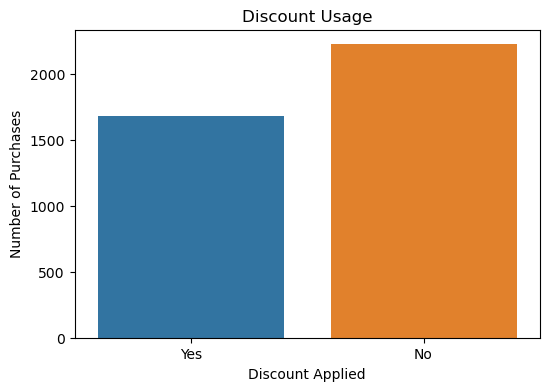

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))

sns.countplot(
    data=df,
    x='discount_applied',
    hue='discount_applied',                 
    palette=['#1f77b4', '#ff7f0e'],             
    ax=ax
)

ax.set_title('Discount Usage')
ax.set_xlabel('Discount Applied')
ax.set_ylabel('Number of Purchases')

plt.show()
